# ***DESBALANCEO DE CLASES***

El dataset presenta una distribución desigual en la variable objetivo **"readmitted"**, lo que convierte el desbalanceo de clases en una problemática central del proyecto. En concreto, los casos de reingreso temprano aparecen en menor proporción que el resto, pese a ser precisamente los más importantes desde el punto de vista clínico. Esto puede hacer que el modelo aprenda patrones que beneficien a las clases mayoritarias y reduzca su capacidad para detectar pacientes que realmente podrían necesitar un mayor seguimiento. En este caso, el problema no es solo técnico, ya que ignorar a la clase minoritaria puede implicar no identificar a pacientes con riesgo elevado de volver a ingresar, lo que afectaría tanto a su salud como a la planificación de recursos del hospital.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.image as mpimg

In [ ]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

Antes de SMOTE:
readmitted
0    41870
1    27719
2     8853
Name: count, dtype: int64

Después de SMOTE:
readmitted
0    41870
1    41870
2    41870
Name: count, dtype: int64


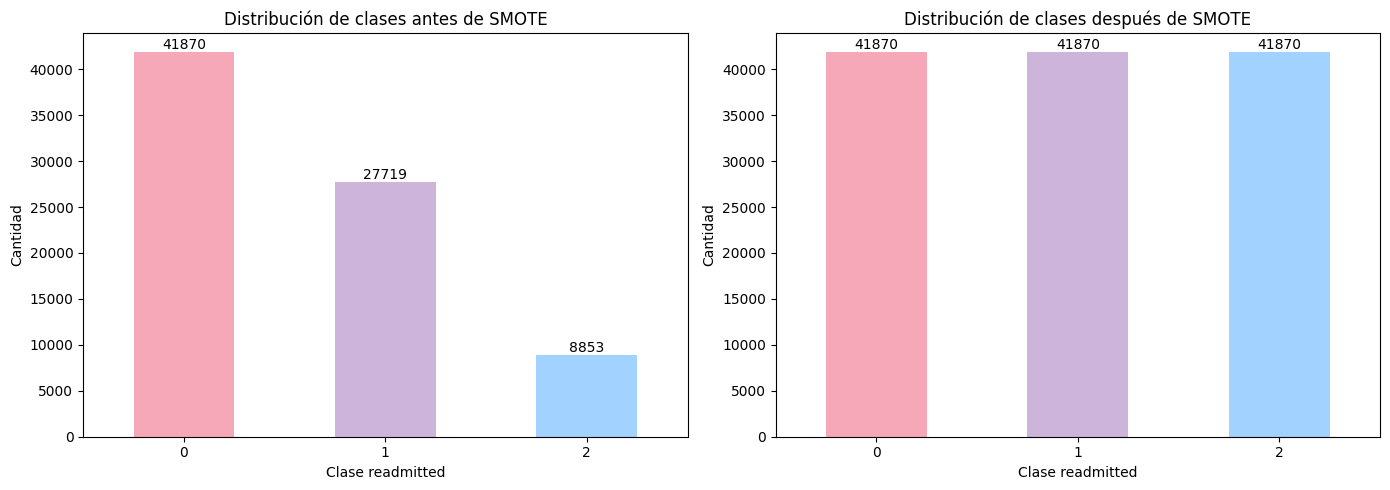

In [ ]:
# Distribución antes de SMOTE
y_train_counts = pd.Series(y_train).value_counts()

print("Antes de SMOTE:")
print(y_train_counts)

# Aplicar SMOTE solo al entrenamiento
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# Distribución después de SMOTE
y_train_smote_counts = pd.Series(y_train_smote).value_counts()

print("\nDespués de SMOTE:")
print(y_train_smote_counts)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF']  

# Antes
y_train_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors
)

axes[0].set_title("Distribución de clases antes de SMOTE")
axes[0].set_xlabel("Clase readmitted")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for p in axes[0].patches:
    axes[0].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Después
y_train_smote_counts.plot(
    kind='bar',
    ax=axes[1],
    color=colors
)

axes[1].set_title("Distribución de clases después de SMOTE")
axes[1].set_xlabel("Clase readmitted")
axes[1].set_ylabel("Cantidad")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for p in axes[1].patches:
    axes[1].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig("../visualizacion_problematicas/smote_distribucion_clases.png", dpi=300, bbox_inches="tight")
plt.show()

Antes de aplicar ninguna técnica de balanceo, la distribución de clases en el conjunto de entrenamiento era muy desigual. Como se observa en la imagen, la clase mayoritaria contiene 41.870 instancias, mientras que las otras clases tienen 27.719 y 8.853 instancias, respectivamente. Esto significa que el modelo dispone de muchos más ejemplos de unas clases que de otras. Esta situación es habitual en problemas clínicos reales, ya que los eventos de mayor interés, como un reingreso temprano, suelen producirse con menor frecuencia.

Como se ha comentado, este desbalanceo es importante porque puede afectar directamente al comportamiento del modelo. Si se entrena un clasificador sobre estos datos, el modelo puede aprender a favorecer las clases mayoritarias, ya que esto le permite obtener buenos resultados sin identificar correctamente los casos menos frecuentes. Como se ha visto durante las fases anteriores de entrenamiento de modelos, una métrica como accuracy puede resultar engañosa, porque un modelo puede alcanzar una precisión aparentemente alta simplemente clasificando correctamente la clase mayoritaria. Sin embargo, al analizar métricas más informativas como el F1-score, se veía que el rendimiento era peor y que el modelo no estaba aprendiendo de forma equilibrada todas las categorías, sino que el desbalanceo estaba afectando a su capacidad para detectar correctamente los casos minoritarios.

En el contexto del problema esto es crítico, ya que un falso negativo, es decir, clasificar como bajo riesgo a un paciente que finalmente será readmitido en menos de 30 días, puede provocar que no reciba seguimiento adicional cuando realmente sí lo necesitaba. Esto puede aumentar el riesgo de complicaciones para el paciente y generar nuevos costes hospitalarios. 

Para tratar el desbalanceo de clases se ha utilizado la técnica SMOTE, que genera ejemplos sintéticos de las clases minoritarias a partir de muestras reales cercanas para equilibrar la distribución de clases. Esto se ha aplicado sobre el conjunto de entrenamiento para evitar data leakage. Si se aplicara antes de separar entrenamiento y test, las muestras sintéticas podrían generarse usando información de datos que después quedarían en el test. Esto haría que el modelo fuese evaluado con datos indirectamente parecidos a los que ya ha visto durante el entrenamiento, dando resultados demasiado optimistas.

Como resultado, tras aplicar SMOTE, las tres clases de quedan equilibradas con 41.870 instancias cada una en el conjunto de entrenamiento. Este resultado se observa claramente en la gráfica comparativa. Antes del tratamiento, la distribución estaba dominada por la clase 0, mientras que la clase 2 tenía una presencia mucho menor. Después de aplicar SMOTE, las tres barras tienen la misma altura, lo que confirma que el conjunto de entrenamiento ha quedado balanceado. De esta forma, durante el aprendizaje, el modelo no se ve tan condicionado por la frecuencia original de las clases.

Una vez analizado el desbalanceo y tratado el problema aplicando SMOTE, se van a voler a entrenar y evalúar diferentes modelos para compararlos con el baseline. Concretamente se va a entrenar un modelo de cada una de las familias utilizadas antes de tratar los problemas. Es decir, se va a utilizar el mejor modelo encontrado para la familia de Árboles de Decisión, para Random Forest y para Gradient Boosting.

## 1- Árboles de decisión

In [5]:
# Árbol de decisión pre-poda 
tree_smote = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=10,
    max_leaf_nodes=None,
    random_state=42
)

# Entrenamiento con el dataset balanceado por SMOTE
tree_smote.fit(X_train_smote, y_train_smote)

# Predicción sobre el test original
y_pred_tree_smote = tree_smote.predict(X_test)

# Métricas
resultados_tree_smote = pd.DataFrame([
    {
        "Modelo": "Decision Tree + SMOTE",
        "Recall": recall_score(y_test, y_pred_tree_smote, average="macro"),
        "Precision": precision_score(y_test, y_pred_tree_smote, average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred_tree_smote),
        "F1-score": f1_score(y_test, y_pred_tree_smote, average="macro")
    }
])

resultados_tree_smote

,Modelo,Recall,Precision,Accuracy,F1-score
0,Decision Tree + SMOTE,0.431884,0.444149,0.555709,0.432094


## 2- Random Forest

In [8]:
seed = 22

# Random Forest 
best_rf = RandomForestClassifier(
    random_state=seed,
    n_jobs=-1,
    oob_score=True,
    bootstrap=True,
    n_estimators=300,
    max_features=None,
    max_depth=30,
    min_samples_leaf=1
)

# Entrenamiento con el dataset balanceado por SMOTE
best_rf.fit(X_train_smote, y_train_smote)

# Predicción sobre el test original
y_pred_rf_smote = best_rf.predict(X_test)

# Tabla de métricas macro
resultados_rf_smote = pd.DataFrame([
    {
        "Modelo": "Random Forest + SMOTE",
        "Recall": recall_score(y_test, y_pred_rf_smote, average="macro"),
        "Precision": precision_score(y_test, y_pred_rf_smote, average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred_rf_smote),
        "F1-score": f1_score(y_test, y_pred_rf_smote, average="macro"),
        "OOB score": best_rf.oob_score_
    }
])

resultados_rf_smote

,Modelo,Recall,Precision,Accuracy,F1-score,OOB score
0,Random Forest + SMOTE,0.438112,0.489431,0.586457,0.433341,0.663984


## 3- Gradient Boosting

In [11]:
# Número de clases
n_clases = len(pd.Series(y_train_smote).unique())

# XGBoost 
xgb_smote = XGBClassifier(
    objective="multi:softprob",
    num_class=n_clases,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=seed,
    n_jobs=1,
    verbosity=0,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    subsample=0.8
)

# Entrenamiento con el dataset balanceado por SMOTE
xgb_smote.fit(X_train_smote, y_train_smote)

# Predicción sobre el test original
y_pred_xgb_smote = xgb_smote.predict(X_test)

# Tabla de métricas macro
resultados_xgb_smote = pd.DataFrame([
    {
        "Modelo": "XGBoost + SMOTE",
        "Recall": recall_score(y_test, y_pred_xgb_smote, average="macro"),
        "Precision": precision_score(y_test, y_pred_xgb_smote, average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred_xgb_smote),
        "F1-score": f1_score(y_test, y_pred_xgb_smote, average="macro")
    }
])

resultados_xgb_smote

,Modelo,Recall,Precision,Accuracy,F1-score
0,XGBoost + SMOTE,0.450441,0.538436,0.606088,0.445814


## 4- Evaluación y comparativa final

In [31]:
columnas_metricas = [
    "Modelo",
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1-Score Macro"
]

# RESULTADOS CON SMOTE
comparativa_smote = pd.DataFrame([
    {
        "Modelo": "Decision Tree + SMOTE",
        "Accuracy": accuracy_score(y_test, y_pred_tree_smote),
        "Precision Macro": precision_score(y_test, y_pred_tree_smote, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_test, y_pred_tree_smote, average="macro"),
        "F1-Score Macro": f1_score(y_test, y_pred_tree_smote, average="macro")
    },
    {
        "Modelo": "Random Forest + SMOTE",
        "Accuracy": accuracy_score(y_test, y_pred_rf_smote),
        "Precision Macro": precision_score(y_test, y_pred_rf_smote, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_test, y_pred_rf_smote, average="macro"),
        "F1-Score Macro": f1_score(y_test, y_pred_rf_smote, average="macro")
    },
    {
        "Modelo": "XGBoost + SMOTE",
        "Accuracy": accuracy_score(y_test, y_pred_xgb_smote),
        "Precision Macro": precision_score(y_test, y_pred_xgb_smote, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_test, y_pred_xgb_smote, average="macro"),
        "F1-Score Macro": f1_score(y_test, y_pred_xgb_smote, average="macro")
    }
])

comparativa_smote = comparativa_smote[columnas_metricas]

comparativa_smote = comparativa_smote.sort_values(
    by="F1-Score Macro",
    ascending=False
).reset_index(drop=True)


# MODELO BASELINE ELEGIDO ANTES DE SMOTE
resultados_antes_desbalanceo = pd.DataFrame([
    {
        "Modelo": "XGBoost",
        "Accuracy": 0.6088,
        "Precision Macro": 0.5467,
        "Recall Macro": 0.4485,
        "F1-Score Macro": 0.4392
    }
])

resultados_antes_desbalanceo = resultados_antes_desbalanceo[columnas_metricas]


# MOSTRAR TABLAS
print("Comparativa de modelos con SMOTE:")
display(comparativa_smote)

print("\nModelo baseline:")
display(resultados_antes_desbalanceo)

Comparativa de modelos con SMOTE:


,Modelo,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,XGBoost + SMOTE,0.606088,0.538436,0.450441,0.445814
1,Random Forest + SMOTE,0.586457,0.489431,0.438112,0.433341
2,Decision Tree + SMOTE,0.555709,0.444149,0.431884,0.432094



Modelo baseline:


,Modelo,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,XGBoost,0.6088,0.5467,0.4485,0.4392


En esta parte se analiza si el tratamiento del desbalanceo mejora los resultados de los modelos. Para ello, se toma como referencia el mejor modelo obtenido antes de aplicar SMOTE, que fue XGBoost, y se compara con los modelos entrenados después de balancear el conjunto de entrenamiento.

El modelo baseline, XGBoost sin SMOTE, obtuvo una accuracy de 0.6088, una precisión de 0.5467, un recall de 0.4485 y un F1-score de 0.4392. Estos resultados sirven como punto de partida para valorar si aplicar SMOTE aporta una mejora real.

Después de aplicar SMOTE, el mejor modelo vuelve a ser XGBoost, con una accuracy de 0.6061, una precisión de 0.5384, un recall de 0.4504 y un F1-score de 0.4458. Al compararlo con el baseline, se observa que la accuracy baja ligeramente, de 0.6088 a 0.6061, y la precisión también disminuye, de 0.5467 a 0.5384. Sin embargo, el recall macro de 0.4485 a 0.4504 y el F1-score macro aumenta de 0.4392 a 0.4458. Por tanto, en el caso de XGBoost, aplicar SMOTE sí mejora ligeramente el resultado si se atiende al F1-score, que es la métrica que se está teniendo en cuenta en este proyecto. La mejora es pequeña, pero los resultados obtenidos son los esperados en un problema con clases desbalanceadas, es decir, se pierde un poco de accuracy y precisión, pero se gana algo de equilibrio en el rendimiento entre clases. En el contexto hospitalario, esta mejora es relevante. En un problema de predicción de reingreso, no interesa únicamente acertar el mayor número total de casos, porque eso puede favorecer a las clases más frecuentes. También interesa que el modelo funcione correctamente con los tipos de reingreso menos representados, ya que justamente son los casos que más interesan. Por eso, métricas como el recall y el F1-score son importantes, porque ayudan a ver si el modelo está funcionando mejor de forma global entre clases, no solo en la clase mayoritaria.

En cambio, Random Forest no mejora al baseline. Obtiene una accuracy de 0.5865, una precisión de 0.4894, un recall de 0.4381 y un F1-score de 0.4333. Todas estas métricas quedan por debajo de las del modelo baseline, salvo que el F1-score se mantiene relativamente cerca. Esto indica que, para Random Forest, aplicar SMOTE no ha sido suficiente para superar el rendimiento del mejor modelo previo. Asimismo, el árbol de decisión tampoco lo mejora. Su accuracy es 0.5557, la precisión es 0.4441, el recall macro es y el F1-score macro es. Por tanto, en este caso, el tratamiento del desbalanceo tampoco supone una mejora frente al modelo de referencia.

Estos resultados muestran que tratar el desbalanceo ayuda en cierta medida, de hecho al comparar cada uno de los modelos con ellos mismos pero cuando no se habían tratado los problemas, se observa que todos mejoran un poco en el F1-score. Sin embargo, tratar este problema no es suficiente por sí solo para conseguir modelos con un rendimiento claramente bueno. Es decir, se puede ver que hay modelos que trabajan con clases desbalanceadas (el baseline) que obtienen mejores resultados que modelos que trabajan con clases balanceadas. Esto puede deberse a que SMOTE equilibra las clases en el conjunto de entrenamiento, pero no cambia la dificultad real del problema ni añade información clínica nueva. En este caso, predecir el reingreso hospitalario es una tarea compleja, porque depende de muchos factores distintos, por eso, aunque el balanceo puede reducir el sesgo hacia las clases mayoritarias, los modelos siguen teniendo dificultades para separar correctamente los distintos tipos de reingreso. Por lo tanto, el desbalanceo era una parte del problema, pero no la única causa de los resultados bajos. Aún así, es muy importante trabajar con clases balanceadas en este contexto para asegurar que el modelo no beneficie a la clase de no reingreso, porque realmente nos interesa más la clase contraria.

En conclusión, el tratamiento del desbalanceo ha tenido un efecto positivo, pero limitado. El mejor resultado se obtiene con XGBoost + SMOTE, que consigue mejorar ligeramente el F1-score respecto al baseline, aunque no logra una mejora clara en todas las métricas. Por tanto, se puede decir que balancear las clases ayuda a que el modelo sea algo más justo entre los distintos tipos de reingreso, pero no resuelve por completo la dificultad del problema. Aun así, en un contexto hospitalario, esta mejora es importante, porque permite reducir la tendencia del modelo a centrarse en las clases más frecuentes y hace que el sistema sea más adecuado para apoyar la detección de pacientes con posible riesgo de reingreso.

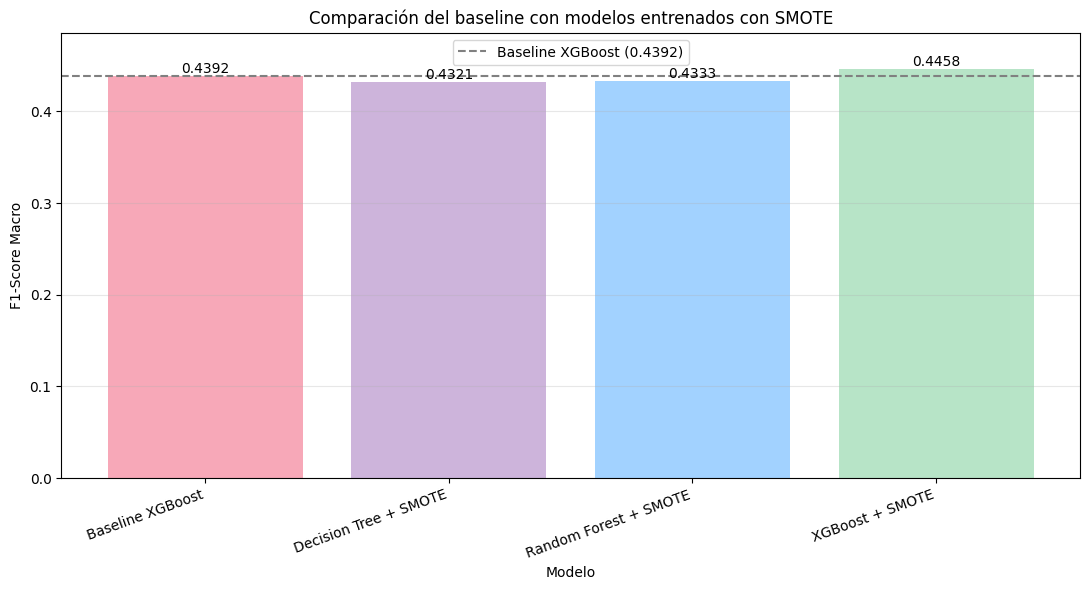

In [33]:
# Copias
baseline = resultados_antes_desbalanceo.copy()
smote = comparativa_smote.copy()

# Asegurarnos de que el baseline solo es XGBoost
baseline = baseline[baseline["Modelo"] == "XGBoost"].copy()
baseline["Modelo"] = "Baseline XGBoost"

# Mantener los modelos con SMOTE
smote = smote.copy()

# Unir baseline + modelos con SMOTE
comparativa_baseline_smote = pd.concat(
    [baseline, smote],
    ignore_index=True
)

# Orden deseado
orden_modelos = [
    "Baseline XGBoost",
    "Decision Tree + SMOTE",
    "Random Forest + SMOTE",
    "XGBoost + SMOTE"
]

comparativa_baseline_smote["Modelo"] = pd.Categorical(
    comparativa_baseline_smote["Modelo"],
    categories=orden_modelos,
    ordered=True
)

comparativa_baseline_smote = comparativa_baseline_smote.sort_values("Modelo")

# Colores pastel
colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF', '#B7E4C7']

# Gráfica F1-Score Macro
plt.figure(figsize=(11, 6))

bars = plt.bar(
    comparativa_baseline_smote["Modelo"],
    comparativa_baseline_smote["F1-Score Macro"],
    color=colors
)

plt.title("Comparación del baseline con modelos entrenados con SMOTE")
plt.xlabel("Modelo")
plt.ylabel("F1-Score Macro")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, comparativa_baseline_smote["F1-Score Macro"].max() + 0.04)
plt.grid(axis="y", alpha=0.3)

# Línea horizontal del baseline
baseline_f1 = baseline["F1-Score Macro"].iloc[0]

plt.axhline(
    y=baseline_f1,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label=f"Baseline XGBoost ({baseline_f1:.4f})"
)

# Valores encima de las barras
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura,
        f"{altura:.4f}",
        ha="center",
        va="bottom"
    )

plt.legend()
plt.tight_layout()
plt.savefig(
    "../visualizacion_problematicas/comparacion_baseline_vs_smote_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

La gráfica anterior muestra de forma visual que el tratamiento del desbalanceo produce una mejora muy ligera respecto al baseline, pero solo en el caso de XGBoost + SMOTE. La línea discontinua representa el F1-score del baseline, que es 0.4392. Tanto el árbol de decisión con SMOTE como Random Forest con SMOTE quedan por debajo de esa referencia, por lo que en estos modelos aplicar SMOTE no mejora el resultado frente al mejor modelo inicial. Esto indica lo que ya se ha explicado, que balancear las clases ayuda un poco, pero no en exceso ni supone un gran cambio en el rendimiento de los modelos. Aún así, la pequeña mejora existe por lo que SMOTE aporta cierto beneficio al modelo más potente. En el contexto del problema, este pequeño aumento es relevante porque se está buscando que el modelo funcione de manera más equilibrada entre los distintos tipos de reingreso, no solo que acierte la clase más frecuente.

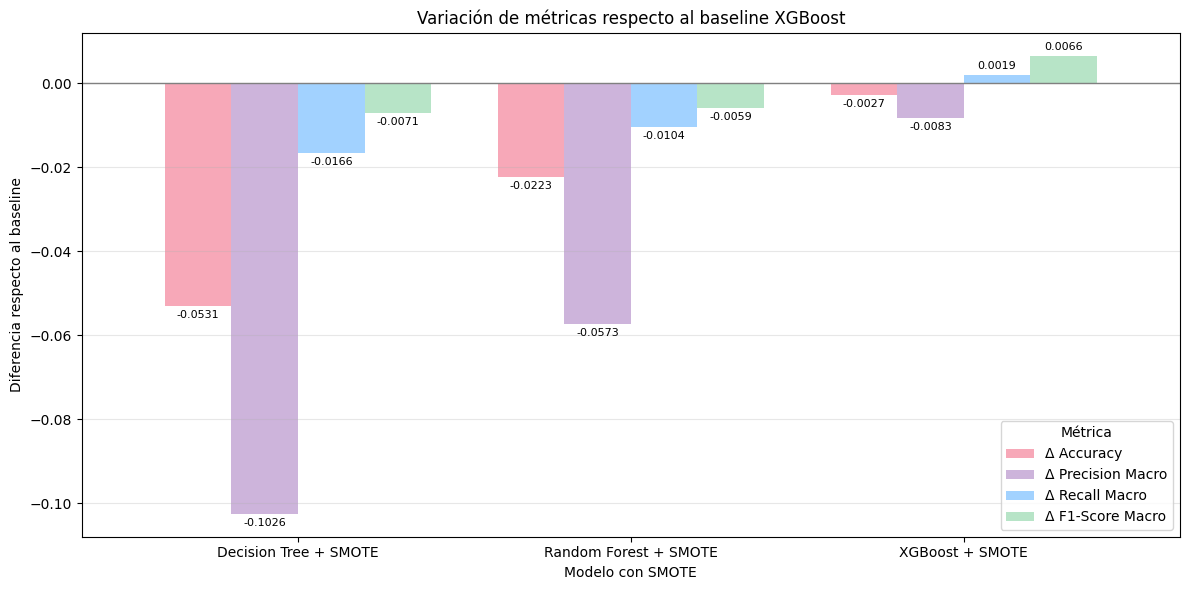

In [34]:
# Copias
baseline = resultados_antes_desbalanceo.copy()
smote = comparativa_smote.copy()

# Quedarnos con el baseline XGBoost
baseline = baseline[baseline["Modelo"] == "XGBoost"].copy()

# Valores del baseline
baseline_values = baseline.iloc[0]

# Crear tabla de diferencias de cada modelo con SMOTE respecto al baseline
diferencias = smote[["Modelo", "Accuracy", "Precision Macro", "Recall Macro", "F1-Score Macro"]].copy()

for metrica in ["Accuracy", "Precision Macro", "Recall Macro", "F1-Score Macro"]:
    diferencias[f"Δ {metrica}"] = diferencias[metrica] - baseline_values[metrica]

# Quedarse solo con diferencias
diferencias = diferencias[
    ["Modelo", "Δ Accuracy", "Δ Precision Macro", "Δ Recall Macro", "Δ F1-Score Macro"]
]

# Orden deseado
orden_modelos = [
    "Decision Tree + SMOTE",
    "Random Forest + SMOTE",
    "XGBoost + SMOTE"
]

diferencias["Modelo"] = pd.Categorical(
    diferencias["Modelo"],
    categories=orden_modelos,
    ordered=True
)

diferencias = diferencias.sort_values("Modelo").set_index("Modelo")

# Colores
colors = ['#F7A8B8', '#CDB4DB', '#A2D2FF', '#B7E4C7']

# Gráfica
ax = diferencias.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=colors
)

plt.axhline(0, linewidth=1, color="gray")
plt.title("Variación de métricas respecto al baseline XGBoost")
plt.xlabel("Modelo con SMOTE")
plt.ylabel("Diferencia respecto al baseline")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

Esta gráfica muestra la diferencia de cada modelo entrenado con SMOTE respecto al baseline. La línea horizontal en cero representa el rendimiento del baseline, de forma que las barras por encima indican mejora, y las barras por debajo indican que el modelo con SMOTE obtiene peores resultados que el baseline.

Básicamente, se puede observar lo que ya se ha comentado, que en general los modelos no aportan una mejora con respecto al baseline. Todas las barras que provienen de modelos de distinta familia del baseline (XGBoost) se encuentran por debajo de la línea horizontal, mientras que del XGBoost + SMOTE sí hay dos que superan (recall y F1-score), aunque se ve que tampoco superan en exceso. 

Esta gráfica resume visualmente el análisis anterior, ya que se observa que aplicar SMOTE no implica una mejora directa. Esto indica que el desbalanceo de clases no era la única causa de los resultados bajos, ni el problema principal que limitaba el rendimiento de los modelos. De hecho, la mejora solo se aprecia al comparar el mismo modelo antes y después del balanceo y aún así no es muy grande. Por tanto, el tratamiento del desbalanceo no transforma de forma significativa el rendimiento general del sistema.

## 5- Importancia de características

In [28]:
if hasattr(X_train, "columns"):
    feature_names = X_train.columns
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

modelos_importancia = {
    "Decision Tree + SMOTE": tree_smote,
    "Random Forest + SMOTE": best_rf,
    "XGBoost + SMOTE": xgb_smote
}

importancias_modelos = {}

# CÁLCULO DE IMPORTANCIAS
for nombre_modelo, modelo in modelos_importancia.items():
    # Importancia interna del modelo
    importances_model = modelo.feature_importances_

    # En árboles sklearn con criterio gini, esto es Gini Importance
    if nombre_modelo in ["Decision Tree + SMOTE", "Random Forest + SMOTE"]:
        nombre_importancia = "Gini Importance"
    else:
        nombre_importancia = "XGBoost Importance"

    # Permutation Importance sobre test original
    perm = permutation_importance(
        modelo,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
        scoring="f1_macro"
    )

    indices = np.argsort(importances_model)[::-1]

    resultados = []

    for rank, idx in enumerate(indices):
        resultados.append({
            "Ranking": rank + 1,
            "Feature": feature_names[idx],
            nombre_importancia: round(importances_model[idx], 4),
            "Permutation Importance": round(perm.importances_mean[idx], 4),
            "Permutation Std": round(perm.importances_std[idx], 4)
        })

    df_importance = pd.DataFrame(resultados)

    importancias_modelos[nombre_modelo] = df_importance

    print(f"\nTop 10 características - {nombre_modelo}")
    display(df_importance.head(10))


Top 10 características - Decision Tree + SMOTE


,Ranking,Feature,Gini Importance,Permutation Importance,Permutation Std
0,1,number_inpatient,0.5666,0.0419,0.0035
1,2,discharge_disposition_id,0.0983,0.0174,0.0013
2,3,encounter_id,0.0608,0.0250,0.0008
3,4,number_diagnoses,0.0570,0.0042,0.0014
4,5,patient_nbr,0.0455,0.0312,0.0011
5,6,number_emergency,0.0311,0.0051,0.0004
6,7,number_outpatient,0.0228,0.0040,0.0006
7,8,time_in_hospital,0.0146,0.0008,0.0006
8,9,age,0.0133,0.0043,0.0007
9,10,diag_1,0.0107,0.0017,0.0005



Top 10 características - Random Forest + SMOTE


,Ranking,Feature,Gini Importance,Permutation Importance,Permutation Std
0,1,number_inpatient,0.1487,0.0334,0.0013
1,2,encounter_id,0.0905,0.0198,0.0018
2,3,patient_nbr,0.0869,0.0290,0.0015
3,4,diag_1,0.0613,0.0040,0.0018
4,5,num_lab_procedures,0.0610,0.0020,0.0015
5,6,diag_2,0.0589,0.0011,0.0015
6,7,diag_3,0.0585,0.0004,0.0014
7,8,num_medications,0.0556,0.0016,0.0015
8,9,time_in_hospital,0.0473,0.0003,0.0011
9,10,number_diagnoses,0.0410,0.0039,0.0022



Top 10 características - XGBoost + SMOTE


,Ranking,Feature,XGBoost Importance,Permutation Importance,Permutation Std
0,1,number_inpatient,0.2052,0.0361,0.0015
1,2,race,0.0582,0.0025,0.0008
2,3,metformin,0.0571,0.0001,0.0008
3,4,number_emergency,0.0472,0.0068,0.0009
4,5,number_outpatient,0.0431,0.0024,0.0008
5,6,number_diagnoses,0.0430,0.0015,0.0015
6,7,change,0.0427,-0.0019,0.0008
7,8,time_in_hospital,0.0425,0.0005,0.0014
8,9,medical_specialty,0.0392,0.0035,0.0008
9,10,discharge_disposition_id,0.0381,0.0200,0.0015


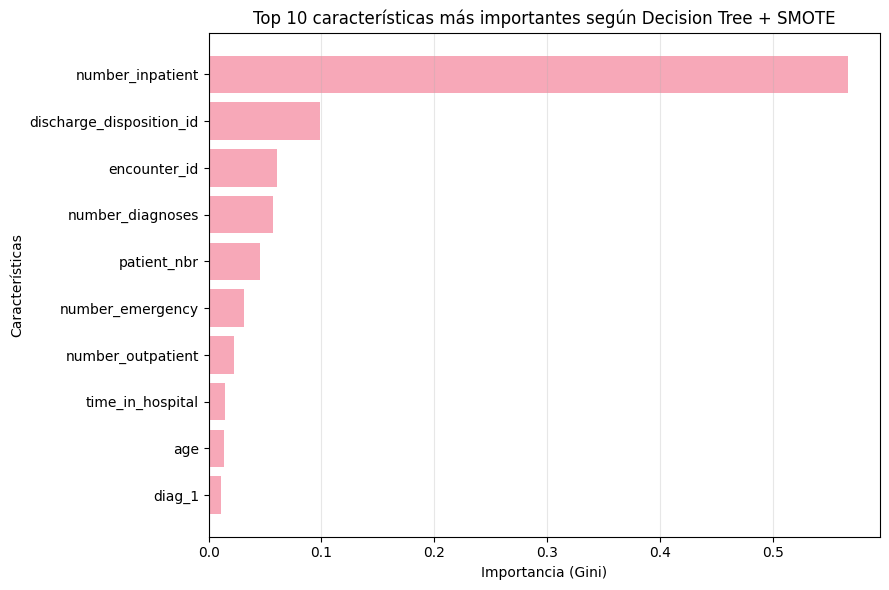

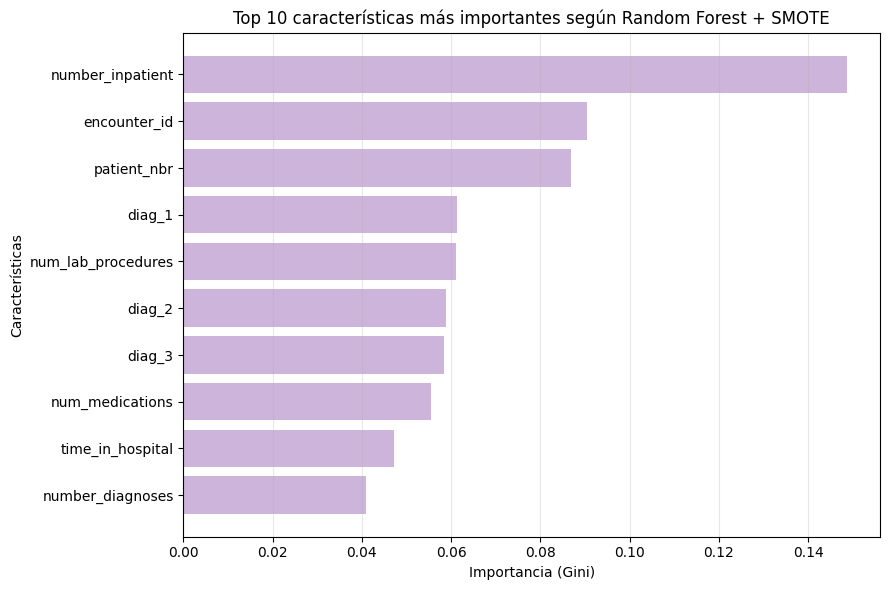

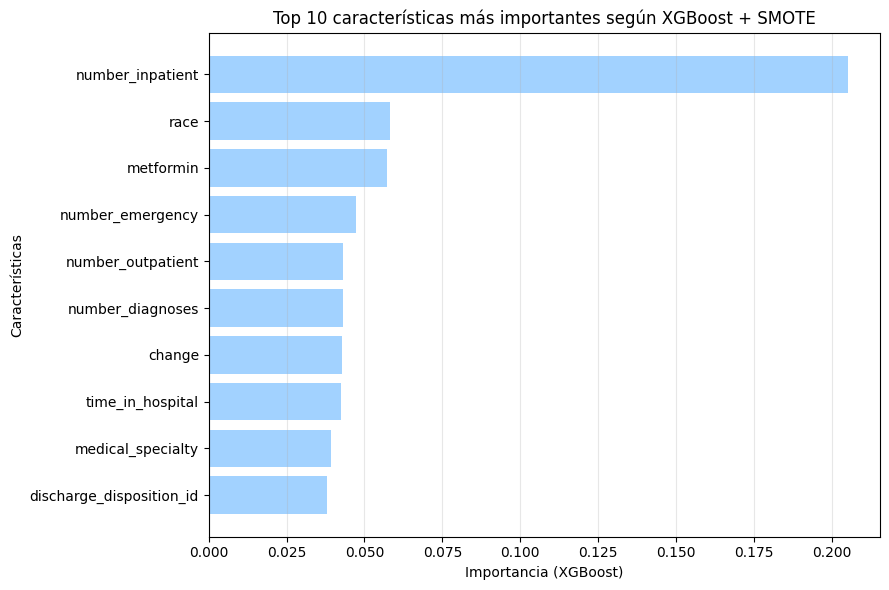

In [29]:
# Colores pastel por modelo
colores_modelos = {
    "Decision Tree + SMOTE": "#F7A8B8",   # rosa pastel
    "Random Forest + SMOTE": "#CDB4DB",   # lila pastel
    "XGBoost + SMOTE": "#A2D2FF"          # azul pastel
}

# Número de características a mostrar
top_n = 10

for nombre_modelo, df_importance in importancias_modelos.items():

    # Elegir la columna de importancia adecuada
    if nombre_modelo in ["Decision Tree + SMOTE", "Random Forest + SMOTE"]:
        columna_importancia = "Gini Importance"
        xlabel = "Importancia (Gini)"
    else:
        columna_importancia = "XGBoost Importance"
        xlabel = "Importancia (XGBoost)"

    # Top N características
    top_features = df_importance.head(top_n)

    plt.figure(figsize=(9, 6))

    plt.barh(
        top_features["Feature"][::-1],
        top_features[columna_importancia][::-1],
        color=colores_modelos[nombre_modelo]
    )

    plt.xlabel(xlabel)
    plt.ylabel("Características")
    plt.title(f"Top {top_n} características más importantes según {nombre_modelo}")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

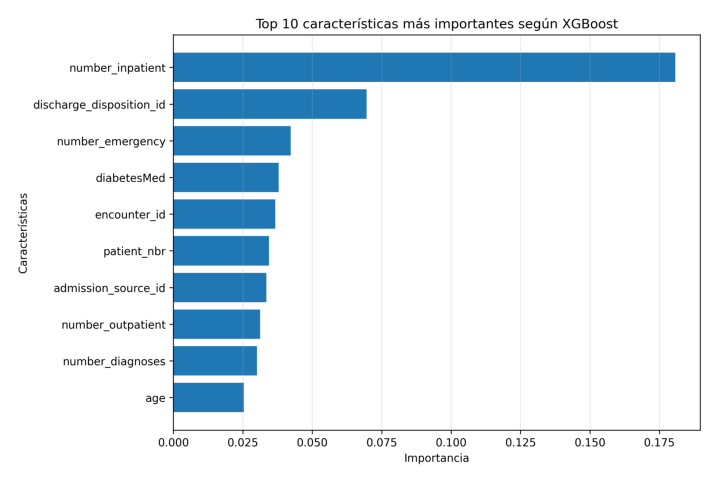

In [37]:
# Ruta de la imagen
ruta_img = "../visualizacion_gradient_boosting/xgboost_importancia_top10.png"

# Cargar imagen
img = mpimg.imread(ruta_img)

# Mostrar imagen
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

En este apartado se analiza qué variables han considerado más importantes los modelos entrenados tras aplicar SMOTE. Este análisis es útil porque permite comprobar si, después de tratar el desbalanceo, los modelos basan sus decisiones en variables con sentido clínico o si aparecen variables menos interpretables.

En los tres modelos entrenados con SMOTE aparece una variable claramente dominante, concretamente **"number_inpatient"**. Esta variable representa el número de ingresos previos del paciente, por lo que tiene sentido que sea la más importante en un problema de predicción de reingreso. Si un paciente ya ha tenido ingresos anteriores, es razonable pensar que puede tener una situación más compleja y una mayor probabilidad de volver a ingresar. Por tanto, que esta variable aparezca como la más relevante es coherente con el contexto hospitalario.

En el árbol de decisión con SMOTE, **"number_inpatient"** tiene una importancia muy superior al resto de variables. Esto indica que el árbol se apoya mucho en esta característica para tomar sus decisiones. Después aparecen variables como **"discharge_disposition_id"**, **"encounter_id"**, **"number_diagnoses"**, **"patient_nbr"**, **"number_emergency"**, **"number_outpatient"**, **"time_in_hospital"**, **"age"** y **"diag_1"**. Algunas de estas variables tienen sentido clínico, como el tipo de alta, el número de diagnósticos, las visitas a urgencias, el tiempo en el hospital o la edad. Sin embargo, también aparecen **"encounter_id"** y **"patient_nbr"**, que son identificadores. Esto es importante porque estos campos no describen realmente el estado clínico del paciente, sino que identifican registros o pacientes. Por tanto, su presencia entre las variables importantes puede indicar que el modelo está aprovechando información que no debería utilizarse para generalizar.

En el Random Forest con SMOTE, también aparece **"number_inpatient"** como la variable más importante, aunque de forma menos extrema que en el árbol de decisión. Esto es esperable, porque Random Forest combina muchos árboles y suele repartir más la importancia entre varias variables. En comparación con el árbol individual, Random Forest tiene en cuenta más variables relacionadas con los datos clínicos del paciente, es decir, diagnósticos, pruebas de laboratorio, medicación y duración de la hospitalización. Esto tiene sentido, ya que un paciente con más diagnósticos, más medicación o más procedimientos puede ser un paciente clínicamente más complejo y, por tanto, con mayor riesgo de reingreso. Aún así, siguen apareciendo los identificadores como en el caso anterior, cuando realmente no debería ser así.

En el caso de XGBoost con SMOTE, la variable más importante vuelve a ser **"number_inpatient"**, con bastante diferencia respecto al resto. Este caso de aquí es interesante porque XGBoost no solo da importancia a variables de uso hospitalario previo, sino también a variables relacionadas con tratamiento y características del paciente. Por ejemplo, **"metformin"** y **"change"** pueden estar relacionadas con el tratamiento de la diabetes, mientras que **"number_emergency"**, **"number_outpatient"** y **"number_diagnoses"** reflejan el historial de asistencia y la complejidad del caso.

Comparando los tres modelos, se ve que hay un grupo de variables que se repite con frecuencia, como **"number_inpatient"**, **"number_emergency"**, **"number_outpatient"**, **"number_diagnoses"**, **"time_in_hospital"** y **"discharge_disposition_id"**. Todas ellas tienen sentido en el problema clínico. En general, describen si el paciente ha necesitado atención médica anteriormente, cuánto tiempo ha estado ingresado, cuántos diagnósticos tiene y en qué condiciones se produce el alta. Estas variables están relacionadas con la gravedad del caso, por lo que es lógico que los modelos las usen para predecir el reingreso Sin embargo, es importante volver a señalar la aparición de identificadores que no deberían interpretarse como factores clínicos reales. 

Al comparar las importancias obtenidas en los modelos con SMOTE frente al baseline, se observa que **"number_inpatient"** sigue siendo la variable más importante en todos los casos. Esto indica que, aunque se haya tratado el desbalanceo y se hayan usado distintos algoritmos, el historial previo de ingresos continúa siendo el factor más determinante. Sin embargo, al aplicar SMOTE aparecen algunas diferencias en el resto de variables. En los modelos con SMOTE ganan peso variables relacionadas con el uso previo de recursos sanitarios, además de variables del alta hospitalaria como **"discharge_disposition_id"**. En cambio, en el baseline también aparecían variables como **"diabetesMed"**, **"admission_source_id"**, **"patient_nbr"** o **"age"**. Esto sugiere que el balanceo no cambia la variable principal sobre la que se apoyan los modelos, pero sí puede modificar parcialmente el peso del resto de características. En general, tras aplicar SMOTE, los modelos parecen centrarse más en variables relacionadas con la utilización previa del sistema sanitario y la complejidad clínica del paciente.

Aun así, hay que interpretar estas importancias con cuidado, porque que una variable sea importante para el modelo no significa que sea la causa directa del reingreso, este es una combinación de muchas variables.